# 03 — Team Stats Deep Dive: Situational Ratings & Matchup Cards

**Goal of this notebook:** go beyond overall EPA and look at teams the way a coordinator does:

1. **Situational splits** — how teams perform by down and by field zone
2. **Team identity** — pass rate over expected (`pass_oe`): who's pass-happy vs run-heavy?
3. **The new situational ratings** — third-down EPA, red-zone EPA, and defensive blitz rate (these are now built by `features.py` and fed to the model)
4. **Matchup cards** — a side-by-side scouting report for any offense vs any defense

Everything here reads from `data/processed/pbp_features.csv`, so it's fast — no need to re-run the pipeline.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# dtype=str on personnel: it's a code like "11", not the number eleven.
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'pbp_features.csv'),
                 low_memory=False, dtype={'personnel': str})
print(df.shape)

(104880, 106)


## 1. Situational splits — EPA by down

League-wide first: how does play-calling success change by down? Early downs are where offenses have freedom; 3rd down is where defenses pin their ears back. (We use raw play rows here, not the rolling features — this is about understanding the game, not feeding the model.)

In [2]:
by_down = df.groupby('down').agg(
    plays=('epa', 'size'),
    epa_per_play=('epa', 'mean'),
    success_rate=('success', 'mean'),
    pass_rate=('play_type', lambda s: (s == 'pass').mean()),
).round(3)
by_down

,plays,epa_per_play,success_rate,pass_rate
down,,,,
1.0,45738,-0.008,0.423,0.477
2.0,34796,0.016,0.448,0.588
3.0,21766,-0.049,0.425,0.748
4.0,2580,0.168,0.545,0.624


### EPA by field zone

`yardline_100` is the distance to the opponent's end zone. We bucket the field into zones — offenses behave very differently backed up against their own goal line vs in the red zone (defenses have less field to defend there, so passing windows shrink).

In [3]:
zones = pd.cut(df['yardline_100'],
               bins=[0, 20, 50, 80, 100],
               labels=['red zone (<=20)', 'plus territory (21-50)',
                       'own side (51-80)', 'backed up (81-100)'])

by_zone = df.groupby(zones, observed=True).agg(
    plays=('epa', 'size'),
    epa_per_play=('epa', 'mean'),
    success_rate=('success', 'mean'),
    pass_rate=('play_type', lambda s: (s == 'pass').mean()),
).round(3)
by_zone

,plays,epa_per_play,success_rate,pass_rate
yardline_100,,,,
red zone (<=20),15955,0.002,0.423,0.503
plus territory (21-50),32855,0.007,0.451,0.569
own side (51-80),47978,-0.011,0.434,0.602
backed up (81-100),8092,-0.021,0.401,0.566


## 2. Team identity — pass rate over expected

`pass_oe` compares each play call to what an average team would do in the same situation. A team can have a high raw pass rate just because they're always trailing — `pass_oe` corrects for that. Positive = chooses to pass more than the situation calls for.

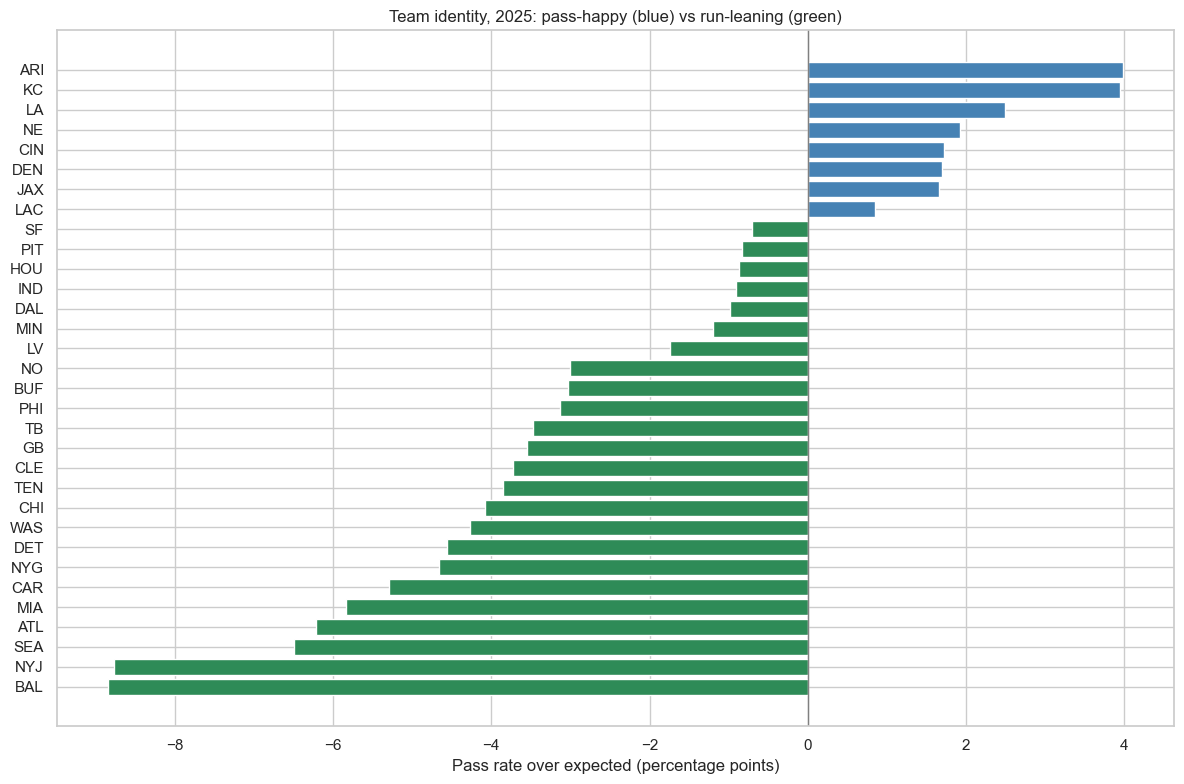

In [4]:
season = df['season'].max()   # most recent season in the data
poe = (df[df['season'] == season]
       .groupby('posteam')['pass_oe'].mean()
       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['steelblue' if v > 0 else 'seagreen' for v in poe.values]
ax.barh(poe.index[::-1], poe.values[::-1], color=colors[::-1])
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('Pass rate over expected (percentage points)')
ax.set_title(f'Team identity, {season}: pass-happy (blue) vs run-leaning (green)')
plt.tight_layout()
plt.show()

## 3. The new situational ratings

`features.py` now also builds rolling previous-4-week versions of:
- `off_epa_third_down` / `def_epa_third_down_allowed` — money-down performance
- `off_epa_redzone` / `def_epa_redzone_allowed` — finishing drives
- `off_pass_oe` — team identity (shown above)
- `def_blitz_rate` — how often the defense sends extra rushers (from FTN)

These are model inputs now. The play-level dataframe carries each team's rating *as of that week*, so to see one row per team-week we deduplicate.

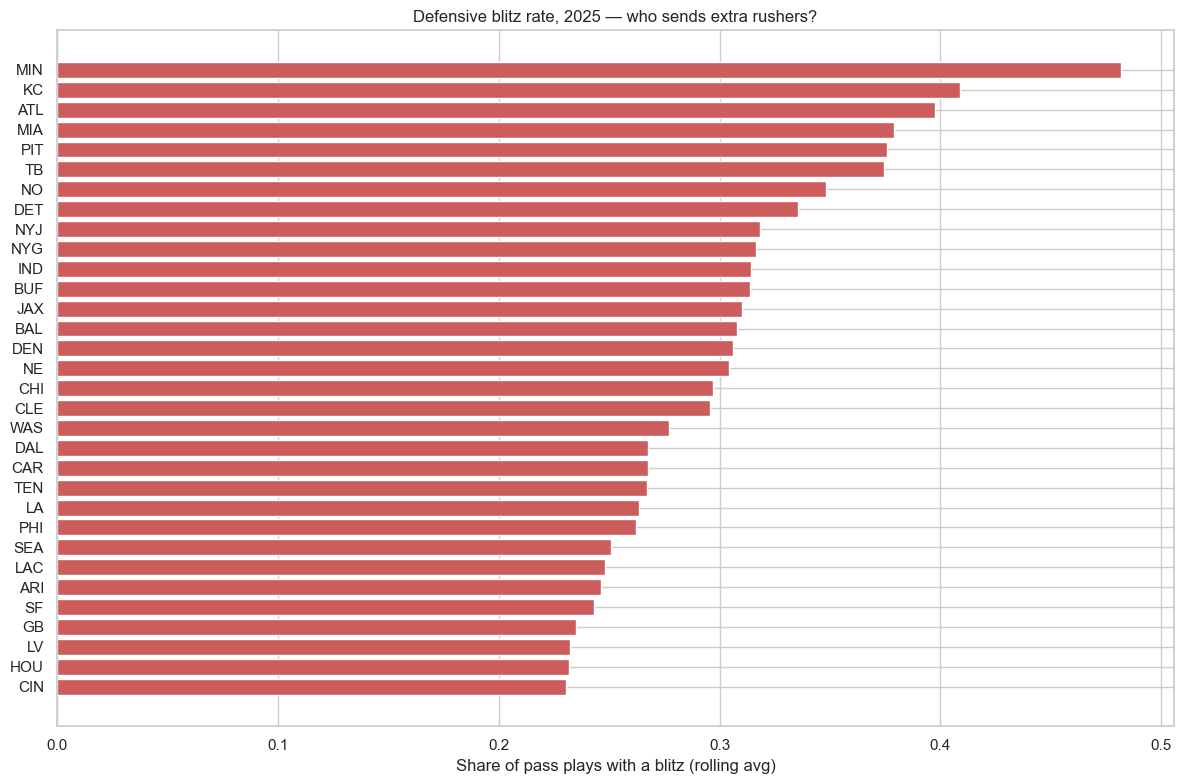

In [5]:
# One row per (season, week, defteam) with that week's rolling ratings
def_weekly = df.drop_duplicates(subset=['season', 'week', 'defteam'])

blitz = (def_weekly[def_weekly['season'] == season]
         .groupby('defteam')['def_blitz_rate'].mean()
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(blitz.index[::-1], blitz.values[::-1], color='indianred')
ax.set_xlabel('Share of pass plays with a blitz (rolling avg)')
ax.set_title(f'Defensive blitz rate, {season} — who sends extra rushers?')
plt.tight_layout()
plt.show()

## 4. Matchup card

The scouting report: one offense's recent form lined up against one defense's, using the rolling ratings for a specific week. This is exactly the information the model sees when it ranks play calls — and later, what the Claude play-caller will narrate.

In [6]:
def matchup_card(posteam, defteam, season, week):
    """Side-by-side scouting report: posteam's offense vs defteam's defense,
    using each team's rolling form as of the given week."""
    off_row = df[(df['posteam'] == posteam) & (df['season'] == season) & (df['week'] == week)]
    def_row = df[(df['defteam'] == defteam) & (df['season'] == season) & (df['week'] == week)]
    if off_row.empty or def_row.empty:
        return f'No data for that week (bye week?). Try another week.'
    off_row, def_row = off_row.iloc[0], def_row.iloc[0]

    card = pd.DataFrame({
        f'{posteam} offense': [
            off_row['off_epa_per_play'], off_row['off_epa_pass'], off_row['off_epa_run'],
            off_row['off_epa_third_down'], off_row['off_epa_redzone'], off_row['off_pass_oe'],
        ],
        f'{defteam} defense (allowed)': [
            def_row['def_epa_allowed_per_play'], def_row['def_epa_allowed_pass'], def_row['def_epa_allowed_run'],
            def_row['def_epa_third_down_allowed'], def_row['def_epa_redzone_allowed'], def_row['def_blitz_rate'],
        ],
    }, index=['EPA/play', 'EPA pass', 'EPA run', 'EPA 3rd down', 'EPA red zone', 'pass_oe / blitz rate'])
    return card.round(3)

# Example: KC's offense vs BUF's defense, week 10 of the latest season
matchup_card('KC', 'BUF', season, 10)

'No data for that week (bye week?). Try another week.'

### Reading the card

- **Offense column**: positive EPA = good. Compare `EPA pass` vs `EPA run` to see where the offense's strength is.
- **Defense column**: these are EPA *allowed*, so **negative = good defense**. If the defense allows positive EPA on passes but negative on runs — throw the ball.
- **Bottom row**: offense's `pass_oe` (identity) next to defense's blitz rate (aggressiveness). A heavy-blitz defense is vulnerable to screens and quick game — exactly the kind of pattern the model can pick up.

Try different matchups and weeks above!

**Next:** `04_model_training.ipynb` — train the model that turns all of this into play recommendations.